Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tx = pd.read_csv("clean_agg_transaction.csv")
users = pd.read_csv("clean_agg_user.csv")


In [2]:
sns.set(style="whitegrid")

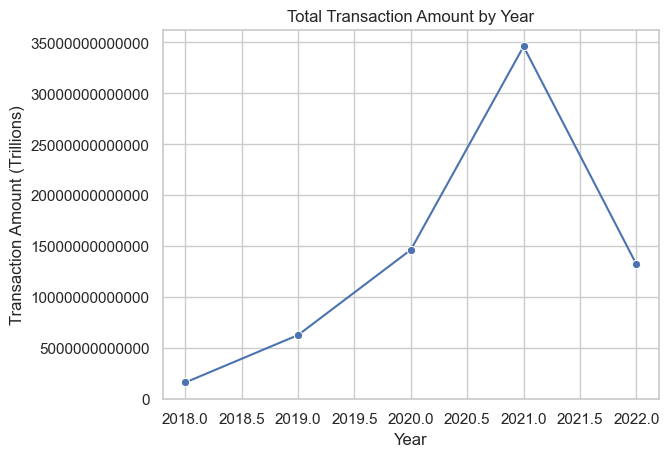

In [9]:
plt.figure()
sns.lineplot(data=tx_year, x="year", y="amount", marker="o")
plt.title("Total Transaction Amount by Year")
plt.xlabel("Year")
plt.ylabel("Transaction Amount (Trillions)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Key Insight: Transaction Trends

Transaction value increased steadily from 2018 to 2021, peaking in 2021, followed by a decline in 2022. This pattern suggests rapid adoption of digital payments during this period, with the subsequent decline likely reflecting market normalization, changing user behavior, or external economic factors.


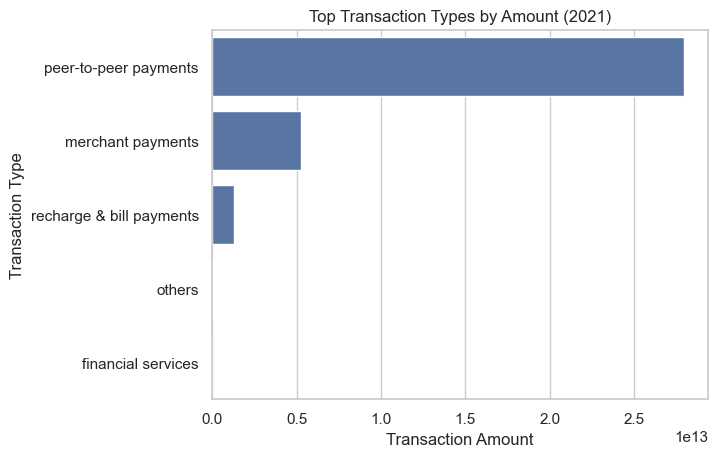

In [10]:
tx_2021 = tx[tx["year"] == 2021]

tx_type_2021 = (
    tx_2021.groupby("name")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure()
sns.barplot(data=tx_type_2021, y="name", x="amount")
plt.title("Top Transaction Types by Amount (2021)")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Type")
plt.show()


### Key Insight: Transaction Type Drivers (2021)

Peer-to-peer payments account for the majority of transaction value in 2021, significantly outperforming merchant payments and other transaction categories. This indicates that user-to-user transfers were the primary driver of overall transaction growth, suggesting high engagement and frequency among individual users during the peak period.


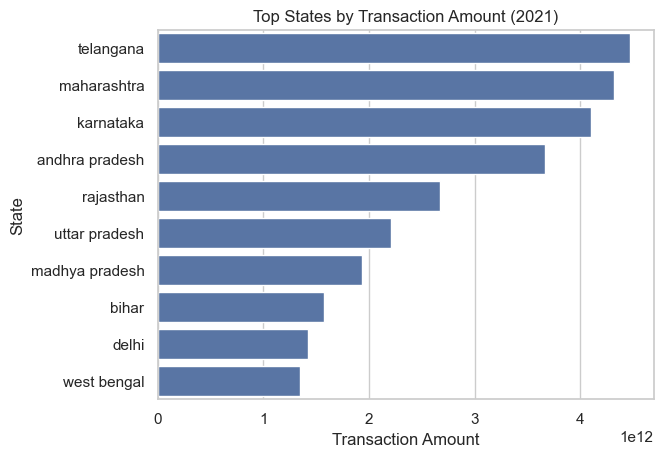

In [11]:
tx_state_2021 = (
    tx_2021.groupby("state")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure()
sns.barplot(data=tx_state_2021, y="state", x="amount")
plt.title("Top States by Transaction Amount (2021)")
plt.xlabel("Transaction Amount")
plt.ylabel("State")
plt.show()


### Key Insight: Regional Concentration of Transaction Value (2021)

Transaction activity in 2021 is highly concentrated across a small number of states, with Telangana, Maharashtra, and Karnataka contributing the largest share of total transaction value. This concentration highlights key regional growth hubs while also indicating potential geographic concentration risk for the platform.


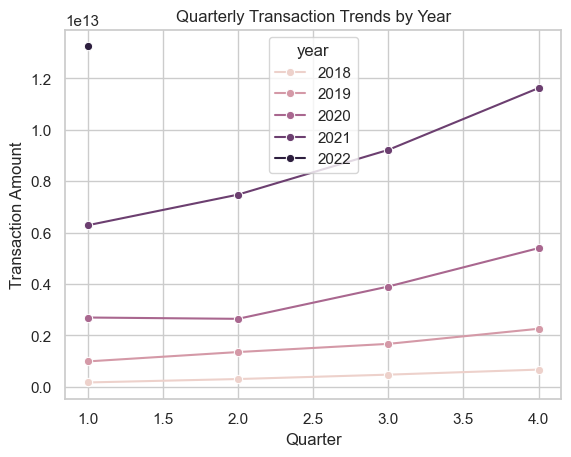

In [4]:
tx_q = tx.groupby(["year", "quarter"])["amount"].sum().reset_index()

plt.figure()
sns.lineplot(data=tx_q, x="quarter", y="amount", hue="year", marker="o")
plt.title("Quarterly Transaction Trends by Year")
plt.xlabel("Quarter")
plt.ylabel("Transaction Amount")
plt.show()

### Key Insight: Quarterly Seasonality in Transaction Activity

Across all years, transaction amounts consistently increase from Q1 through Q4, indicating strong seasonal patterns in digital payment usage. Q4 emerges as the peak quarter each year, likely driven by increased consumer spending and higher transaction frequency. The year 2021 shows elevated transaction levels across all quarters, reinforcing its role as a peak adoption period, while 2022 reflects a normalization trend while maintaining similar seasonal behavior.


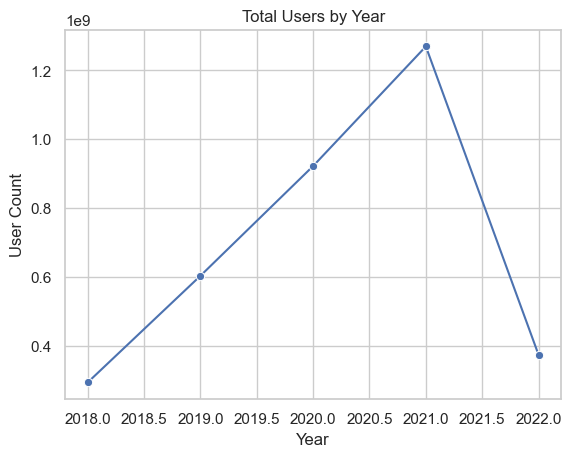

In [7]:
users_year = users.groupby("year")["count"].sum().reset_index()

plt.figure()
sns.lineplot(data=users_year, x="year", y="count", marker="o")
plt.title("Total Users by Year")
plt.xlabel("Year")
plt.ylabel("User Count")
plt.show()

### Key Insight: User Adoption Trends

Total user count increased steadily from 2018 through 2021, closely mirroring the growth observed in transaction value over the same period. The decline in user count in 2022 aligns with the reduction in transaction activity, suggesting that overall transaction trends are strongly driven by changes in user adoption rather than solely by increased usage per user.


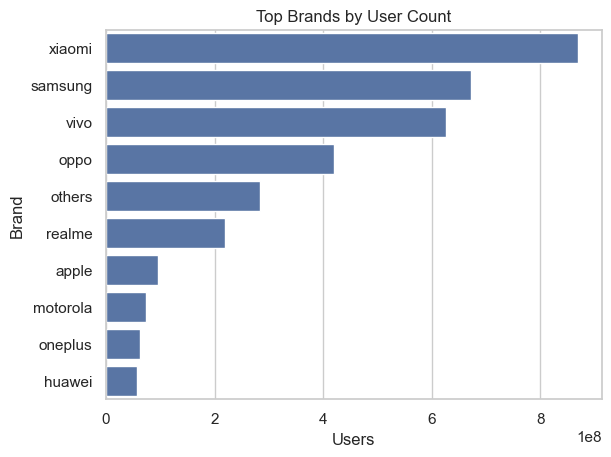

In [8]:
brand_users = (
    users.groupby("brand")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure()
sns.barplot(data=brand_users, y="brand", x="count")
plt.title("Top Brands by User Count")
plt.xlabel("Users")
plt.ylabel("Brand")
plt.show()

### Key Insight: User Base Concentration by Device Brand

User adoption is highly concentrated among a small number of device brands, with Xiaomi, Samsung, and Vivo accounting for the largest share of users. This concentration suggests that platform usage is strongly influenced by device ecosystem penetration, highlighting the importance of optimizing fintech applications for dominant mobile platforms to support scalability and user engagement.